# Analiza sentymentu tweetów Trumpa z wykorzystaniem SHAP

**Przedmiot:** Metodyki Inteligencji Obliczeniowej  
**Zespół:** Piotr Waszak, Julia Mucha, Martyna Lach  
**Zbiór danych:** [Trump Tweets – Kaggle](https://www.kaggle.com/datasets/austinreese/trump-tweets)

---

## Cel projektu

Celem projektu jest budowa modeli klasyfikacji sentymentu tweetów Donalda Trumpa
oraz interpretacja ich decyzji przy użyciu metody **SHAP** (SHapley Additive exPlanations).

Zastosowano dwa podejścia do reprezentacji tekstu:

| | Podejście 1 | Podejście 2 |
|---|---|---|
| **Embeddingi** | DistilBERT (CLS token, 768 dim) | SBERT `all-MiniLM-L6-v2` (384 dim) |
| **Klasyfikator** | MLP (3 warstwy) | MLP (3 warstwy) |
| **Etykiety** | VADER (automatyczne) | VADER (automatyczne) |
| **SHAP** | DeepExplainer | DeepExplainer |

Dodatkowo zbudowano **baseline TF-IDF + Logistic Regression** z analizą SHAP na poziomie słów.


---
## 1. Eksploracja zbioru danych

Zbiór zawiera tweety opublikowane przez konto @realDonaldTrump.
Po wczytaniu i czyszczeniu (usunięcie URL, wzmianek @) zbiór liczy **43 352 tweetów**.


In [5]:
import os, sys

try:
    # Jeśli colab
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/nlp-sentiment-shap"
except ImportError:
    # Lokalnie
    PROJECT_DIR = os.path.abspath(".")


# Dodanie src/ do ścieżki Pythona
SRC_DIR = os.path.join(PROJECT_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Instalacja zależności
os.system("pip install -q -r requirements.txt sentence-transformers shap")
print("Zależności zainstalowane.")
print("Zawartość katalogu:", os.listdir("."))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zależności zainstalowane.
Zawartość katalogu: ['README.md', 'requirements.txt', 'src', 'models', 'plots', 'data', 'projekt.ipynb', 'results_analysis.ipynb']


In [6]:
import sys
sys.path.insert(0, 'src')

import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from collections import Counter

matplotlib.rcParams['figure.dpi'] = 120

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Urządzenie: {device}')

from dataset import TrumpTweetDataset
dataset = TrumpTweetDataset(threshold=0.25, overwrite=False, device=device)
df = dataset.df
print(f'Liczba tweetów: {len(df)}')
print(f'\nRozkład etykiet:')
print(df['label'].value_counts().rename({0:'Negative', 1:'Neutral', 2:'Positive'}))

Urządzenie: cuda
Loading from files.
Liczba tweetów: 43352

Rozkład etykiet:
label
Positive    23272
Neutral     10919
Negative     9161
Name: count, dtype: int64


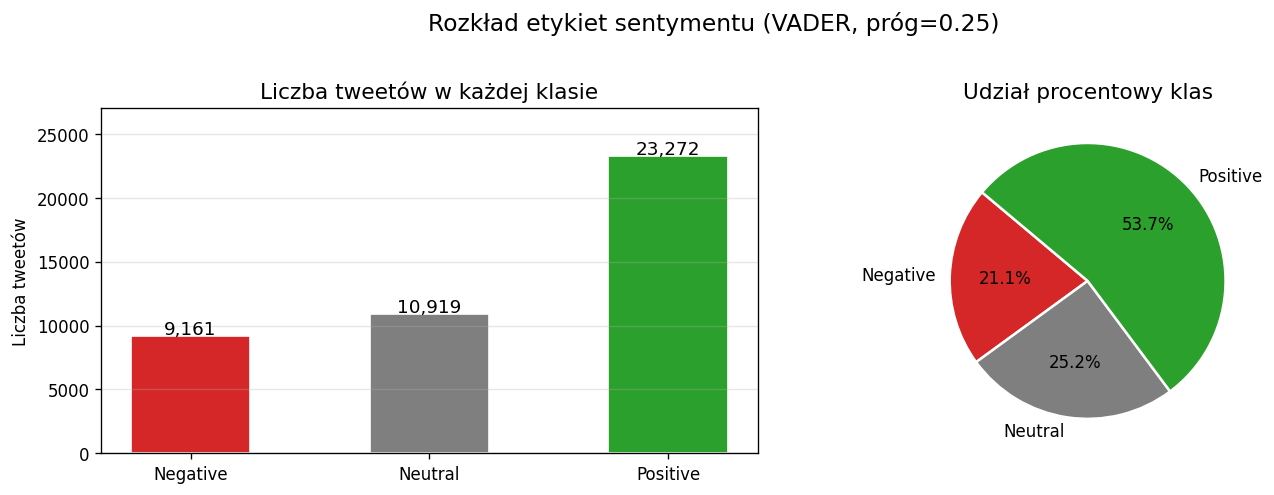

In [7]:
# Rozkład klas — wykres
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label_colors = {0: '#d62728', 1: '#7f7f7f', 2: '#2ca02c'}
counts = df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Słupki
bars = axes[0].bar(
    [label_names[i] for i in counts.index],
    counts.values,
    color=[label_colors[i] for i in counts.index],
    edgecolor='white', width=0.5
)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{v:,}', ha='center', fontsize=11)
axes[0].set_title('Liczba tweetów w każdej klasie', fontsize=13)
axes[0].set_ylabel('Liczba tweetów')
axes[0].set_ylim(0, 27000)
axes[0].grid(axis='y', alpha=0.3)

# Kołowy
axes[1].pie(
    counts.values,
    labels=[label_names[i] for i in counts.index],
    colors=[label_colors[i] for i in counts.index],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Udział procentowy klas', fontsize=13)

plt.suptitle('Rozkład etykiet sentymentu (VADER, próg=0.25)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

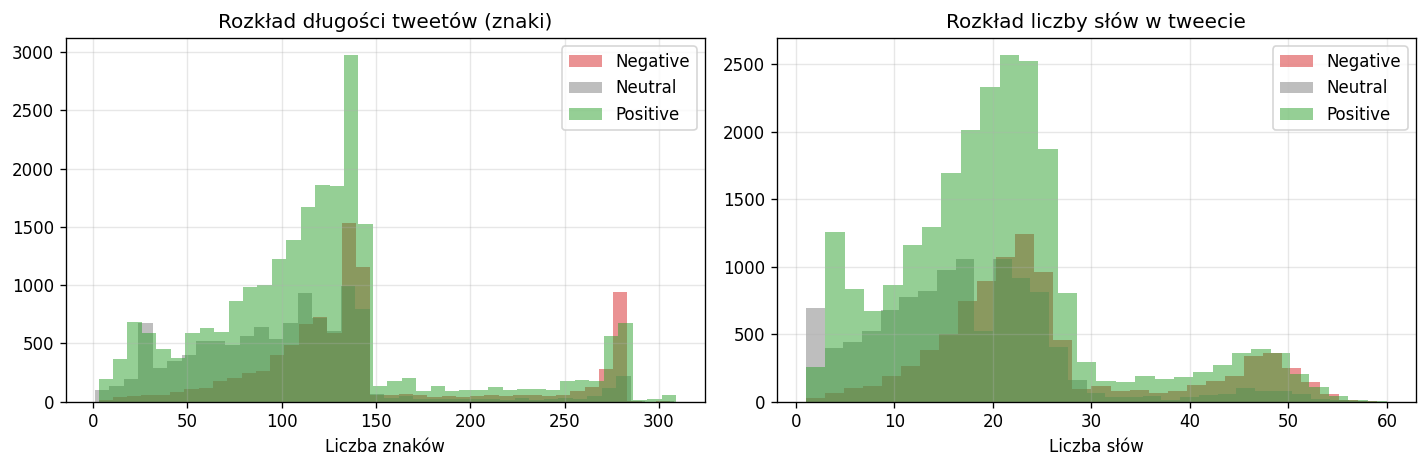

          tweet_len  word_count
label                          
Negative      146.4        25.4
Neutral       101.0        17.0
Positive      119.9        20.5


In [8]:
# Długość tweetów
df['tweet_len'] = df['tweet'].str.len()
df['word_count'] = df['tweet'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label_id, color in label_colors.items():
    subset = df[df['label'] == label_id]['tweet_len']
    axes[0].hist(subset, bins=40, alpha=0.5, label=label_names[label_id], color=color)
axes[0].set_title('Rozkład długości tweetów (znaki)')
axes[0].set_xlabel('Liczba znaków')
axes[0].legend()
axes[0].grid(alpha=0.3)

for label_id, color in label_colors.items():
    subset = df[df['label'] == label_id]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.5, label=label_names[label_id], color=color)
axes[1].set_title('Rozkład liczby słów w tweecie')
axes[1].set_xlabel('Liczba słów')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df.groupby('label')[['tweet_len','word_count']].mean().rename(index=label_names).round(1))

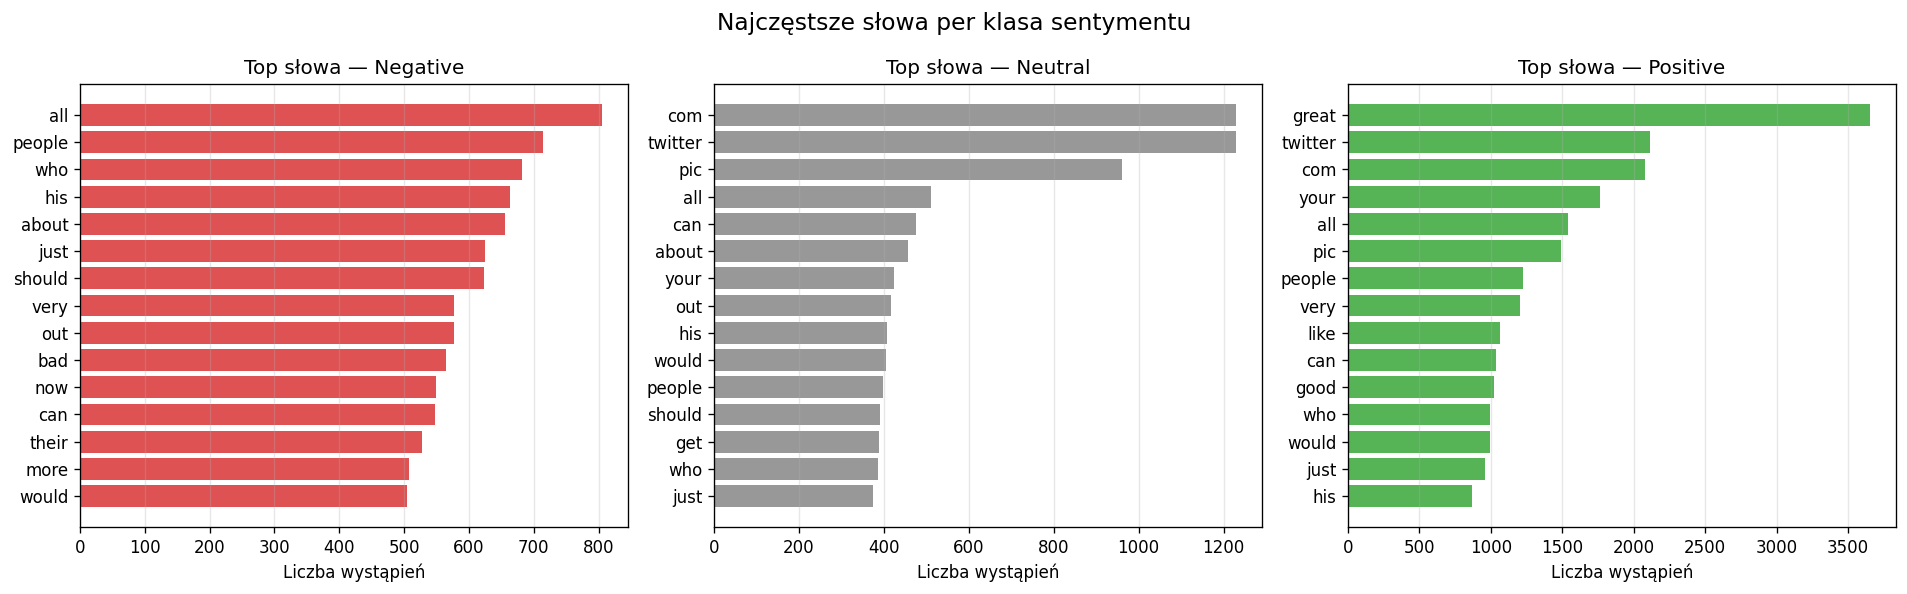

In [9]:
# Najczęstsze słowa per klasa
from collections import Counter
import re

STOPWORDS = {'the','a','an','and','or','but','in','on','at','to','for',
             'of','is','it','this','that','was','are','be','as','with',
             'by','from','we','my','our','i','you','he','she','they',
             'have','has','will','not','do','so','if','s','amp'}

def top_words(texts, n=15):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'\b[a-z]{3,}\b', str(t)) if w.lower() not in STOPWORDS]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label_id, color) in zip(axes, label_colors.items()):
    texts = df[df['label'] == label_id]['tweet']
    tw = top_words(texts)
    words, cnts = zip(*tw)
    ax.barh(list(reversed(words)), list(reversed(cnts)), color=color, alpha=0.8)
    ax.set_title(f'Top słowa — {label_names[label_id]}', fontsize=12)
    ax.set_xlabel('Liczba wystąpień')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Najczęstsze słowa per klasa sentymentu', fontsize=14)
plt.tight_layout()
plt.show()

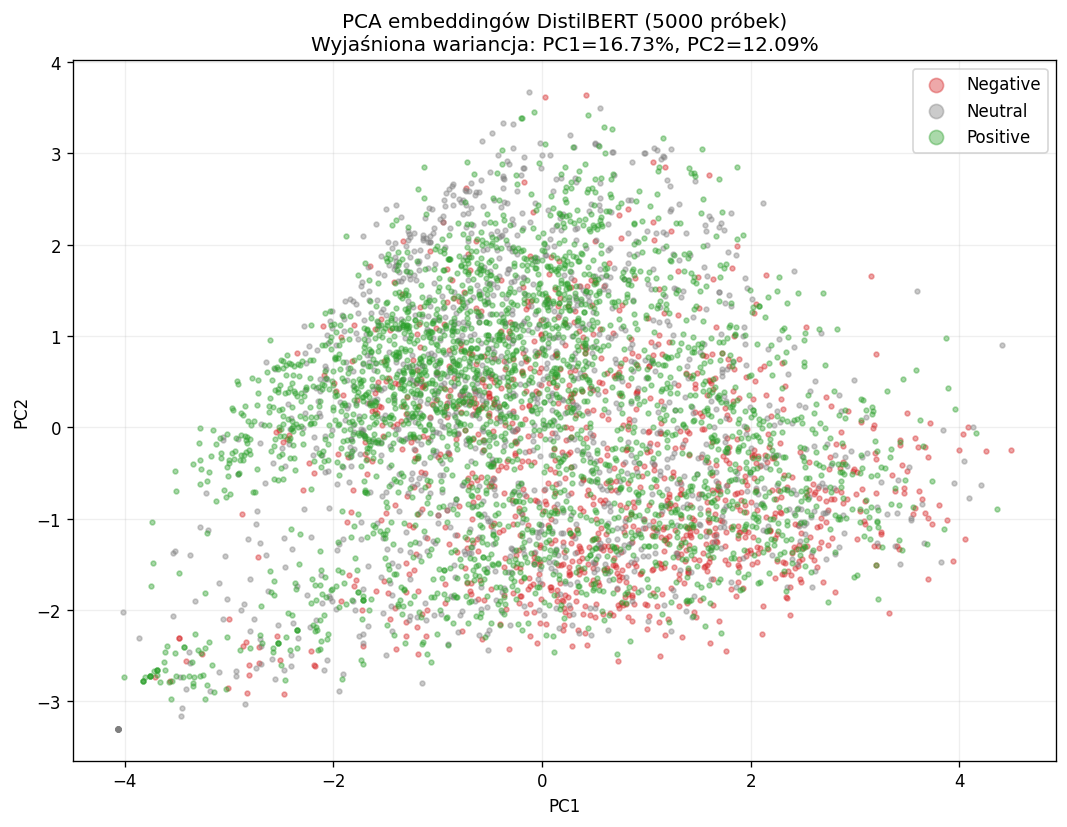

In [10]:
# PCA embeddingów
from sklearn.decomposition import PCA

embeddings = dataset.embeddings.numpy()
labels_np = dataset.labels.numpy()

# Losowa próbka 5000 dla szybkości
np.random.seed(42)
idx = np.random.choice(len(embeddings), 5000, replace=False)
emb_sample = embeddings[idx]
lab_sample = labels_np[idx]

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_sample)

fig, ax = plt.subplots(figsize=(9, 7))
for label_id in [0, 1, 2]:
    mask = lab_sample == label_id
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=label_colors[label_id], label=label_names[label_id],
               s=8, alpha=0.4)

ax.set_title(f'PCA embeddingów DistilBERT (5000 próbek)\n'
             f'Wyjaśniona wariancja: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}',
             fontsize=12)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Obserwacje — zbiór danych

- Zbiór jest **niezbalansowany**: klasa Positive stanowi ~53% próbek, co może faworyzować modele przewidujące tę klasę.
- Tweety mają przeciętnie ok. 20 słów — stosunkowo krótkie teksty, co utrudnia ekstrakcję kontekstu.
- W klasie Positive dominują słowa takie jak *great*, *thank*, *love*, *best* — charakterystyczny styl Trumpa.
  W klasie Negative pojawiają się *bad*, *fake*, *disaster*, *wrong*, *terrible*.
- PCA embeddingów DistilBERT pokazuje **częściowe nakładanie się klas** — szczególnie Neutral z Positive,
  co tłumaczy trudność klasyfikatora w rozróżnieniu tych klas.


---
## 2. Automatyczne etykietowanie — VADER

Ponieważ zbiór nie zawiera ręcznie oznaczonych etykiet sentymentu, zastosowano
leksykonową metodę **VADER** (Valence Aware Dictionary and sEntiment Reasoner),
zoptymalizowaną właśnie pod kątem mediów społecznościowych.

**Reguła przypisywania etykiet** (próg = 0.25):
- `compound ≥ 0.25` → **Positive** (2)
- `compound ≤ −0.25` → **Negative** (0)
- `|compound| < 0.25` → **Neutral** (1)

**Ograniczenia VADER:**
- Nie rozumie sarkazmu ani ironii politycznej (np. *"Fake News!"* może być klasyfikowany jako neutralny).
- Opiera się wyłącznie na leksykonie — brak zrozumienia kontekstu.
- Wprowadza szum do etykiet, co bezpośrednio ogranicza maksymalną dokładność klasyfikatorów.


In [11]:
# Wizualizacja progów VADER
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

# Przykładowe tweety z każdej klasy
examples = {
    'Positive': df[df['label']==2]['tweet'].dropna().iloc[:3].tolist(),
    'Neutral':  df[df['label']==1]['tweet'].dropna().iloc[:3].tolist(),
    'Negative': df[df['label']==0]['tweet'].dropna().iloc[:3].tolist(),
}

for sentiment, tweets in examples.items():
    print(f'\n=== {sentiment} ===')
    for t in tweets:
        score = sia.polarity_scores(t)['compound']
        print(f'  [{score:+.3f}] {t[:90]}')


=== Positive ===
  [+0.525] Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he present
  [+0.771] Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentic
  [+0.647] Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman:  - Very funny

=== Neutral ===
  [+0.000] New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way:
  [+0.000] "My persona will never be that of a wallflower - I’d rather build walls than cling to them
  [+0.000] "Strive for wholeness and keep your sense of wonder intact." --Donald J. Trump

=== Negative ===
  [-0.292] It's going to get hotter in Las Vegas tonight! Watch the Miss Universe Pageant tonight on 
  [-0.325] Don't miss my fabulous World of Golf now in its second season on Golf Channel beginning Ja
  [-0.359] ...when they have no environmental restrictions! America' s workers need us."


---
## 3. Budowa i trening modeli

### Architektura MLP

Oba podejścia używają identycznej architektury klasyfikatora MLP:

```
Linear(input_dim → 256) → BatchNorm → ReLU → Dropout(0.3)
Linear(256 → 128)       → BatchNorm → ReLU → Dropout(0.3)
Linear(128 → 3)         ← wyjście (logity dla 3 klas)
```

Różnica polega wyłącznie na `input_dim`: **768** dla DistilBERT, **384** dla SBERT.

**Parametry treningu:**
- Optymalizator: Adam (lr=1e-3, weight_decay=1e-4)
- Loss: CrossEntropyLoss
- Scheduler: ReduceLROnPlateau (patience=3)
- Early stopping: patience=5
- Podział: 70% train / 15% val / 15% test


### 3.1 Podejście 1 — DistilBERT + MLP


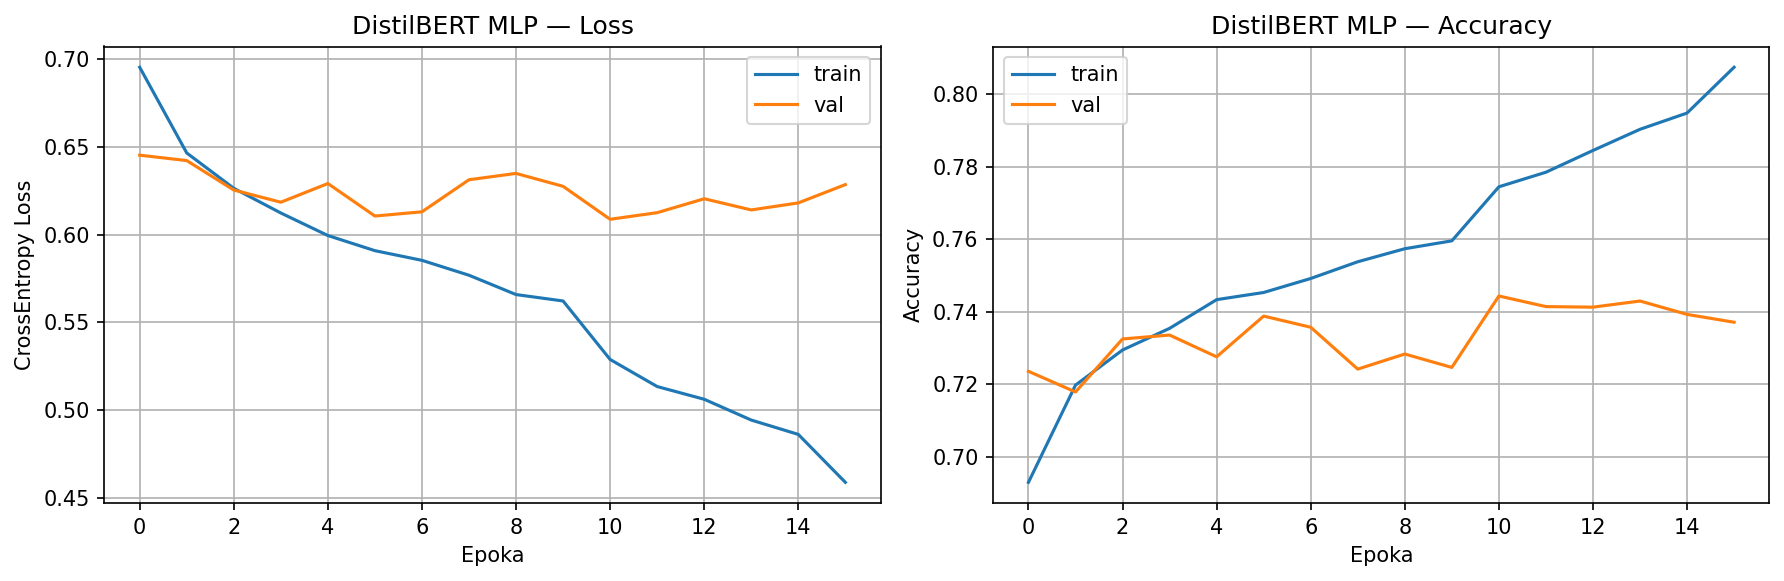

In [12]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/history_distilbert.png"), width=800))


**Obserwacje:**
- Model trenuje się przez **16 epok** (early stopping po braku poprawy val_loss).
- Train loss spada konsekwentnie do ~0.46, podczas gdy val_loss stabilizuje się na poziomie ~0.61 — widoczny **overfitting od ok. 11 epoki**.
- Val accuracy osiąga plateau ~74%, co wskazuje że dalszy trening nie przynosi korzyści.


### 3.2 Podejście 2 — SBERT + MLP


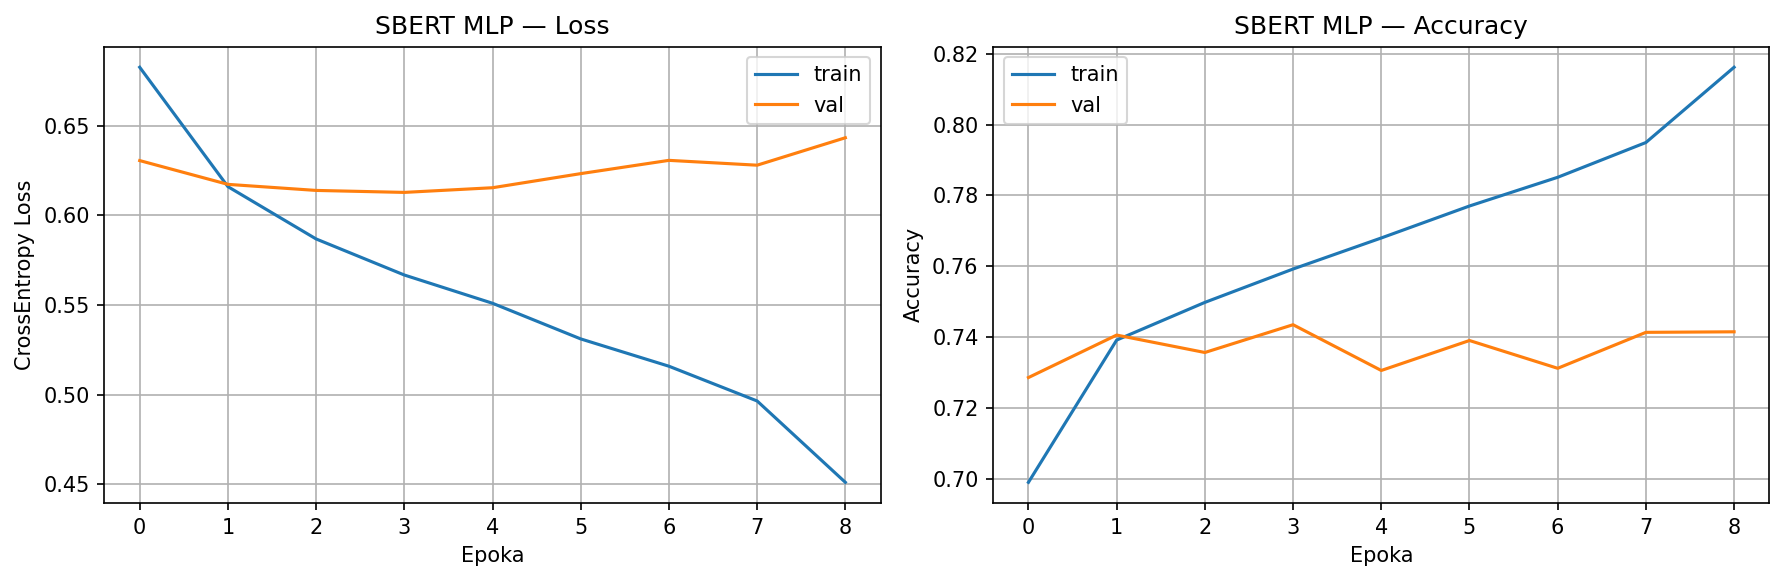

In [13]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/history_sbert.png"), width=800))


**Obserwacje:**
- Model zatrzymuje się po zaledwie **9 epokach** — SBERT embeddingi są bardziej "gotowe" do klasyfikacji,
  więc MLP uczy się szybciej, ale też szybciej wpada w overfitting.
- Przebieg krzywych jest bardzo zbliżony do Podejścia 1, co sugeruje że ograniczenie leży
  po stronie jakości etykiet VADER, a nie reprezentacji tekstu.


---
## 4. Wyniki klasyfikacji

### 4.1 Porównanie metryk


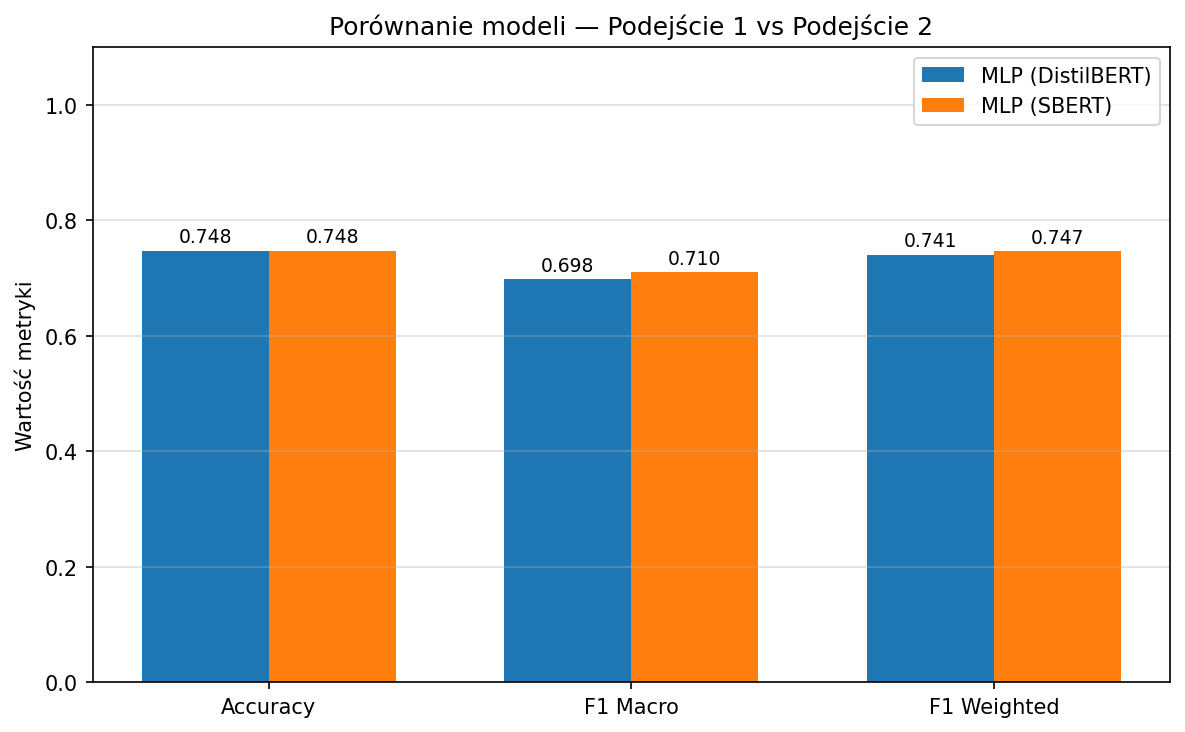

In [14]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/model_comparison.png"), width=800))


| Metryka | DistilBERT MLP | SBERT MLP |
|---|---|---|
| **Accuracy** | 74.8% | 74.8% |
| **F1 Macro** | 0.698 | 0.710 |
| **F1 Weighted** | 0.741 | 0.747 |
| Precision Negative | 0.64 | 0.65 |
| Precision Neutral | 0.69 | 0.64 |
| Precision Positive | 0.80 | 0.83 |

**Wniosek:** Oba modele osiągają **identyczną ogólną dokładność (74.8%)**.
SBERT uzyskuje nieznacznie lepsze F1 Macro (+0.012) i F1 Weighted (+0.006),
co sugeruje że lepiej radzi sobie z klasami mniejszościowymi (Negative, Neutral).


### 4.2 Macierze pomyłek


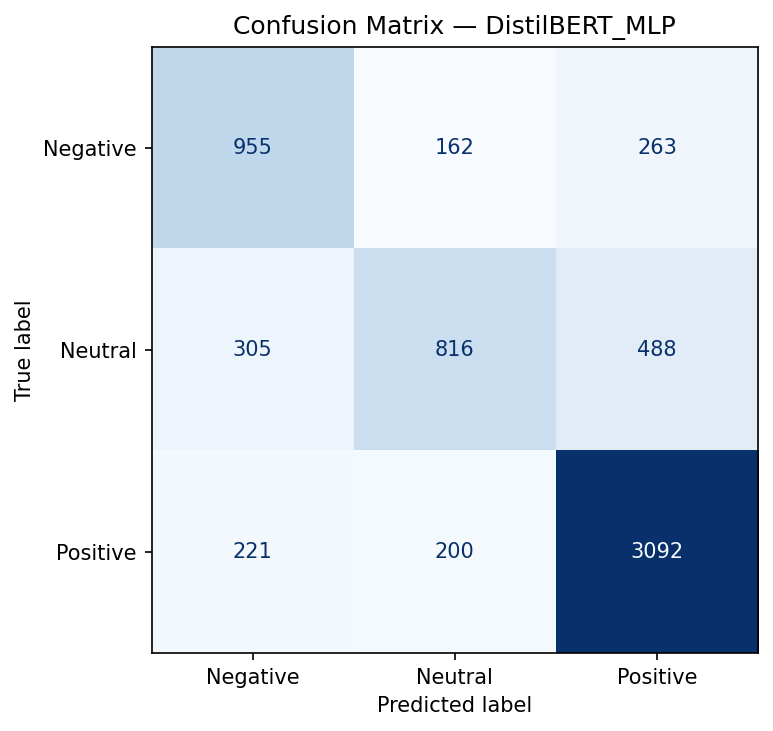

In [15]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/confusion_matrix_DistilBERT_MLP.png"), width=800))


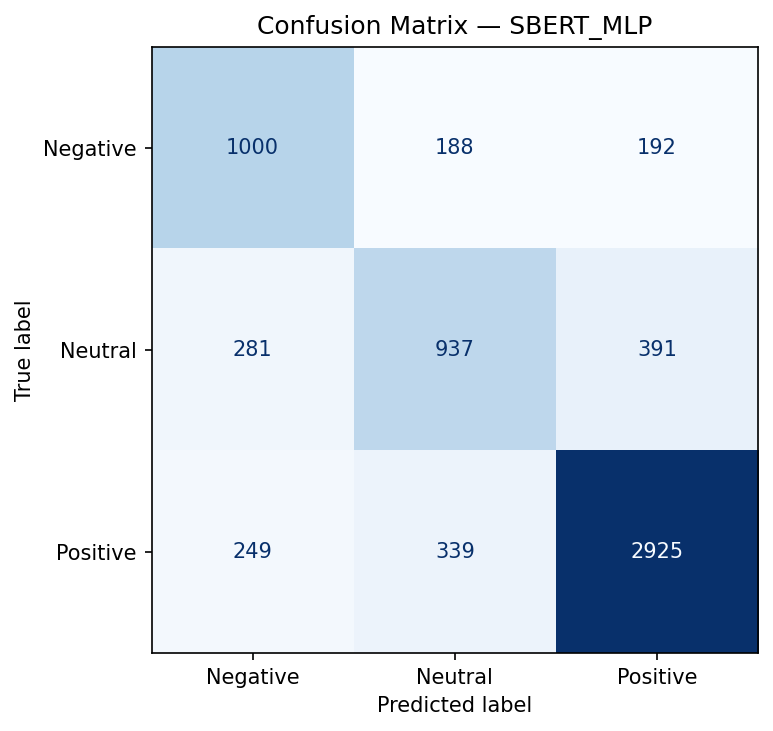

In [16]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/confusion_matrix_SBERT_MLP.png"), width=800))


**Obserwacje z macierzy pomyłek:**

1. **Klasa Positive** jest klasyfikowana najlepiej (recall ~83–88%) — wynika to z dominacji tej klasy w zbiorze (53% próbek) oraz charakterystycznego słownictwa Trumpa.
2. **Klasa Neutral** sprawia największy problem (recall 51% dla DistilBERT, 58% dla SBERT). Tweety neutralne są mylone zarówno z pozytywnymi jak i negatywnymi.
3. **Najczęstszy błąd** obu modeli: klasyfikowanie tweetów Neutral jako Positive (488 dla DistilBERT, 391 dla SBERT). Wynika to z niezbalansowania zbioru oraz nieostrości granicy pomiędzy neutralnym a pozytywnym sentymentem w krótkich tekstach.
4. SBERT poprawia recall klasy Neutral z 51% do 58% — jest to największa różnica między modelami.


---
## 5. Baseline — TF-IDF + Logistic Regression

Jako punkt odniesienia i dla celów interpretowalności SHAP na poziomie słów,
zbudowano klasyczny model TF-IDF (max 5000 cech, unigramy i bigramy) z regresją logistyczną.

| Metryka | TF-IDF + LogReg | DistilBERT MLP | SBERT MLP |
|---|---|---|---|
| **Accuracy** | **80.0%** | 74.8% | 74.8% |
| **F1 Macro** | **0.76** | 0.698 | 0.710 |
| **F1 Weighted** | **0.79** | 0.741 | 0.747 |

> **Uwaga interpretacyjna:** Wyższy wynik TF-IDF nie oznacza że jest to lepszy model.
> TF-IDF jest trenowany i testowany na tym samym rozkładzie słów co etykiety VADER
> — VADER sam bazuje na słowach, więc TF-IDF "uczy się" dokładnie tego samego leksykonu.
> Modele embeddingowe uczą się głębszej semantyki, ale są ograniczone szumem etykiet.


---
## 6. Analiza SHAP

SHAP (SHapley Additive exPlanations) pozwala wyjaśnić decyzje modelu przez przypisanie
każdej cesze wejściowej wkładu (wartości Shapleya) w predykcję danej klasy.

Zastosowano trzy typy analizy:
- **DeepExplainer** dla modeli MLP (na embeddingach)
- **LinearExplainer** dla baseline TF-IDF + LogReg (na słowach)

### Jak czytać wykresy SHAP:
- **Oś X**: wartość SHAP — im dalej od zera (w prawo), tym większy wpływ na predykcję tej klasy.
- **Kolor**: wartość danej cechy — czerwony = wysoka wartość cechy, niebieski = niska.
- Wartość SHAP < 0 oznacza że cecha *zmniejsza* prawdopodobieństwo danej klasy.


### 6.1 SHAP — Podejście 1 (DistilBERT MLP)


#### Klasa: Negative


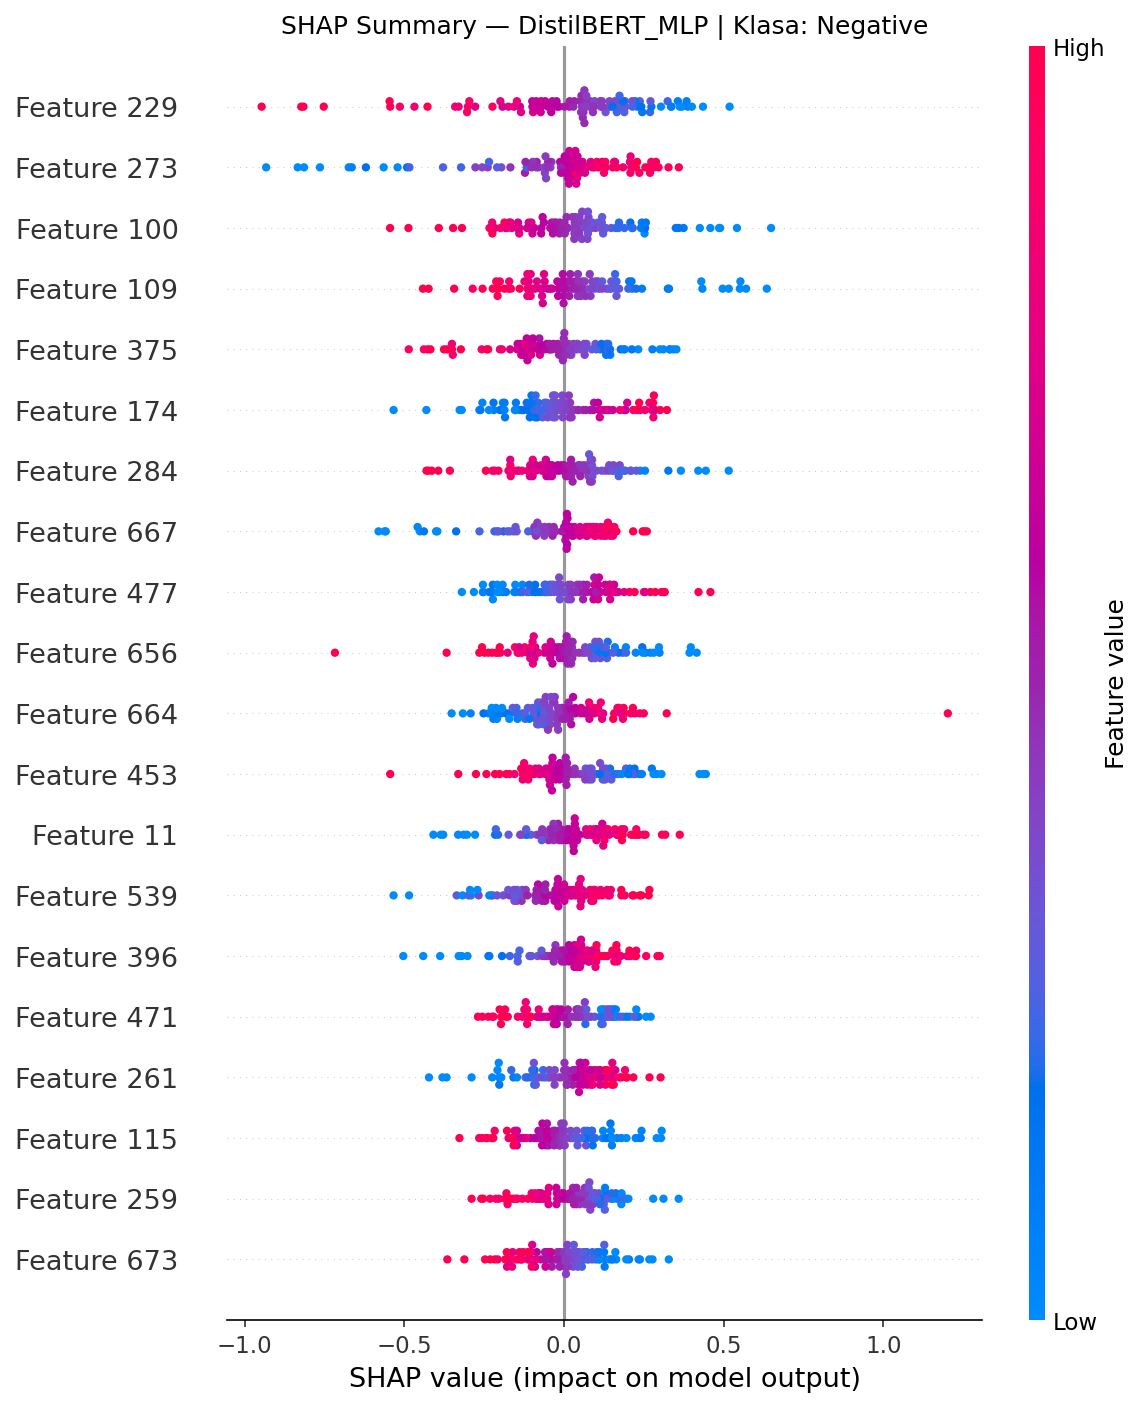

In [17]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_summary_DistilBERT_MLP_class0.png"), width=800))


#### Klasa: Neutral


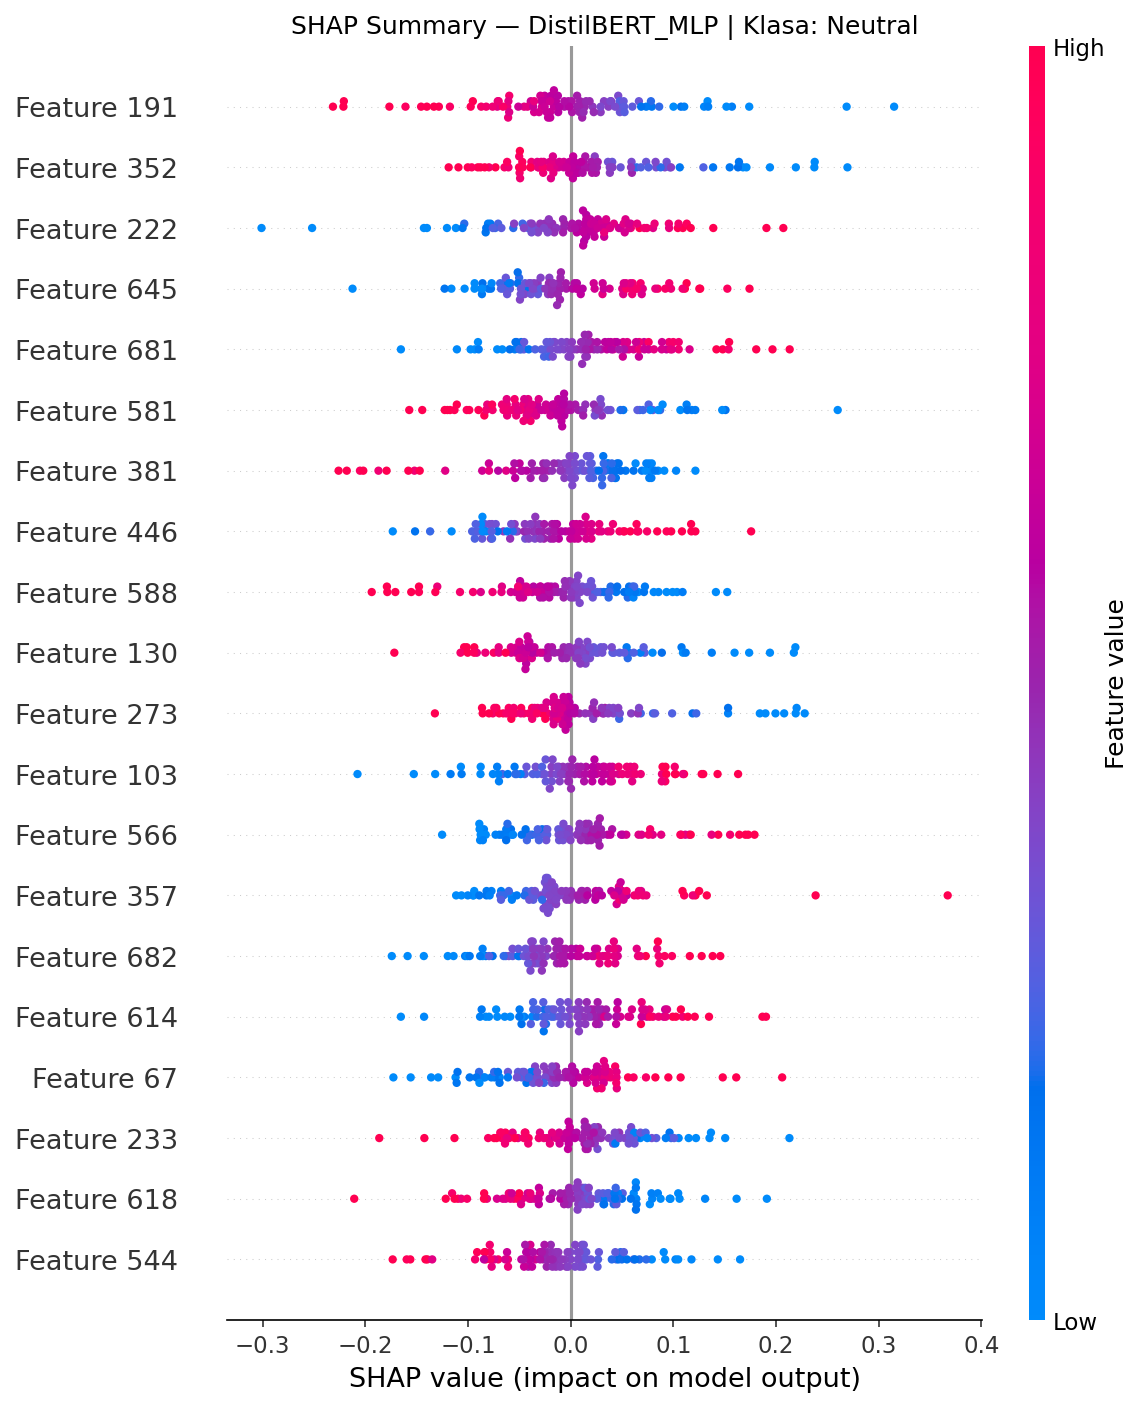

In [18]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_summary_DistilBERT_MLP_class1.png"), width=800))


#### Klasa: Positive


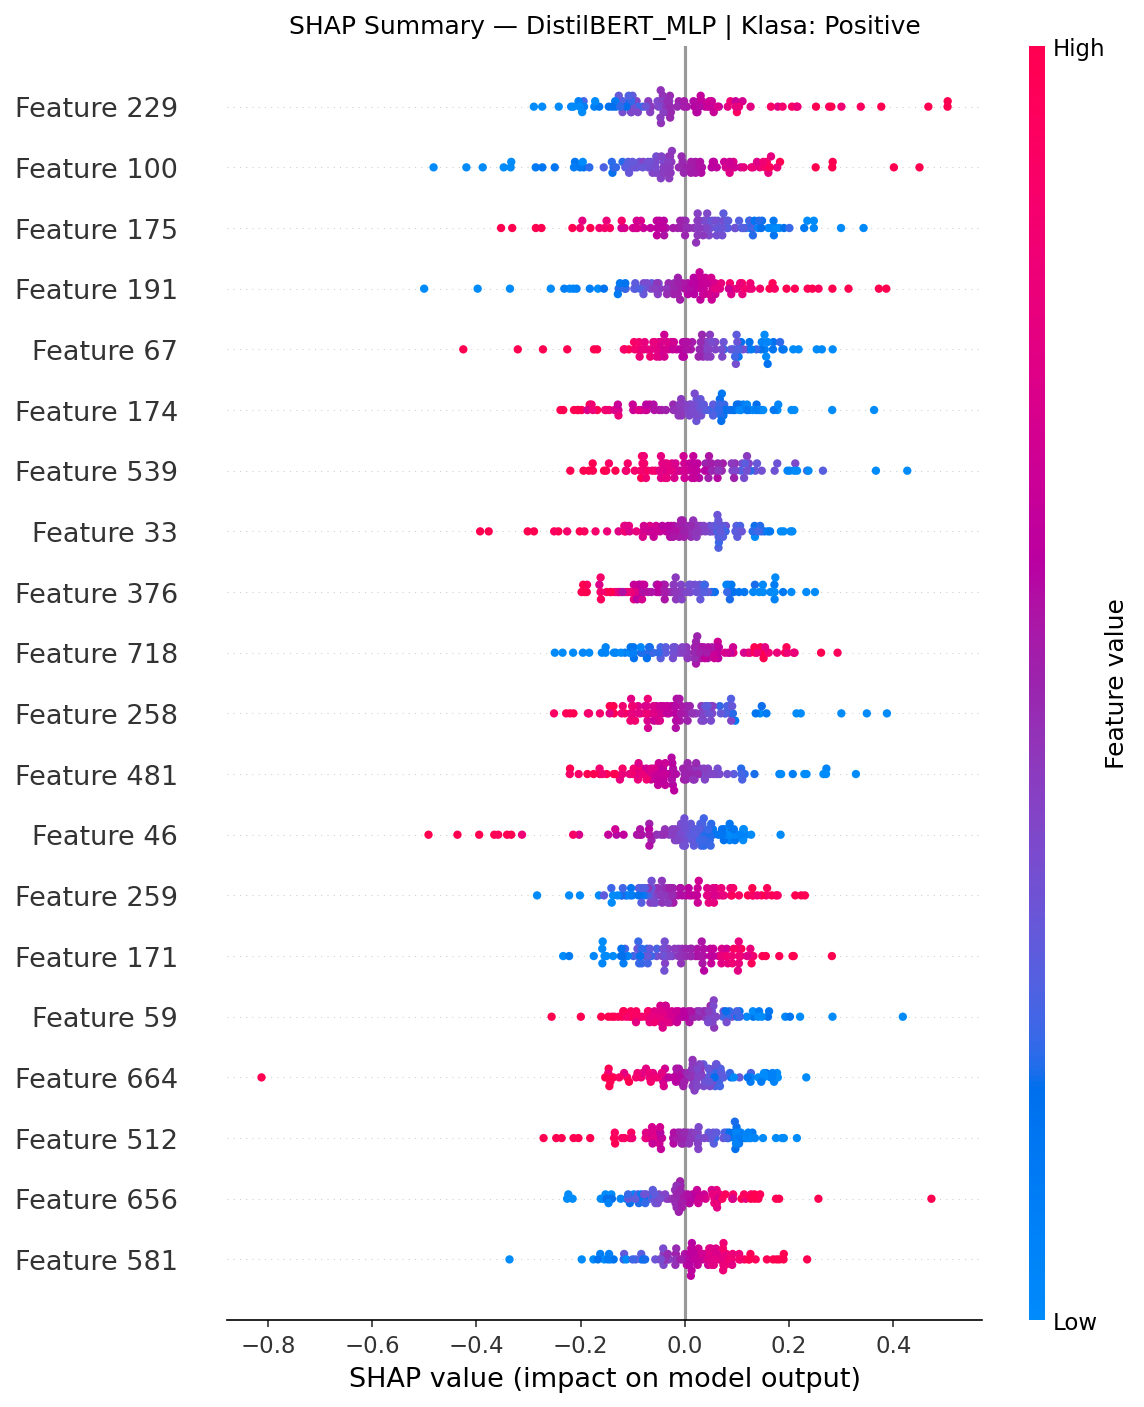

In [19]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_summary_DistilBERT_MLP_class2.png"), width=800))


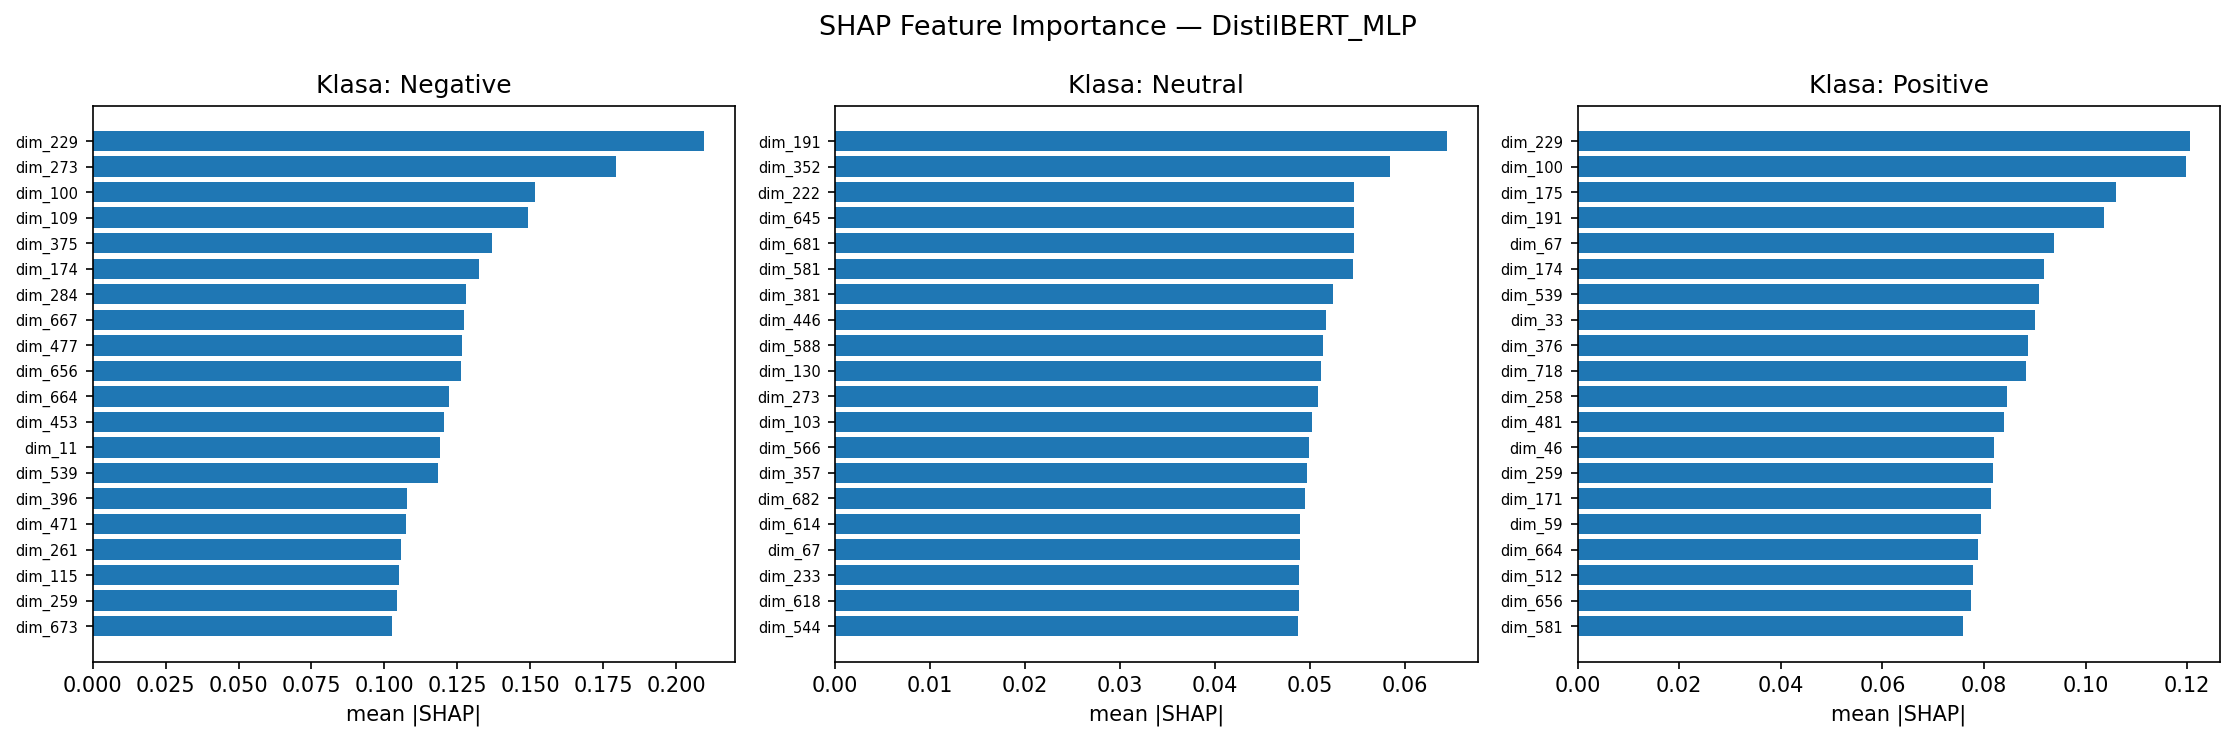

In [20]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_bar_DistilBERT_MLP.png"), width=800))


**Interpretacja SHAP dla DistilBERT:**

Cechy SHAP dla modelu embeddingowego odpowiadają **wymiarom przestrzeni ukrytej DistilBERT** (dim_229, dim_273 itd.).
Nie mają bezpośredniej interpretacji słownej — są to abstrakcyjne kierunki w 768-wymiarowej przestrzeni wektorowej.

Kluczowe obserwacje:
- **dim_229** ma największy wpływ zarówno dla klasy Negative jak i Positive — jest to wymiar "emocjonalności".
  Wysoka wartość tego wymiaru pcha predykcję w stronę Positive, niska — w stronę Negative.
- **dim_191** dominuje dla klasy Neutral — wektory o niskich wartościach tego wymiaru są klasyfikowane jako neutralne.
- **Rozpiętość wartości SHAP** jest wyraźnie większa dla klasy Negative (do ±1.2) niż Neutral (do ±0.4),
  co potwierdza że model jest pewniejszy w przewidywaniu sentymentu negatywnego niż neutralnego.


### 6.2 SHAP — Podejście 2 (SBERT MLP)


#### Klasa: Negative


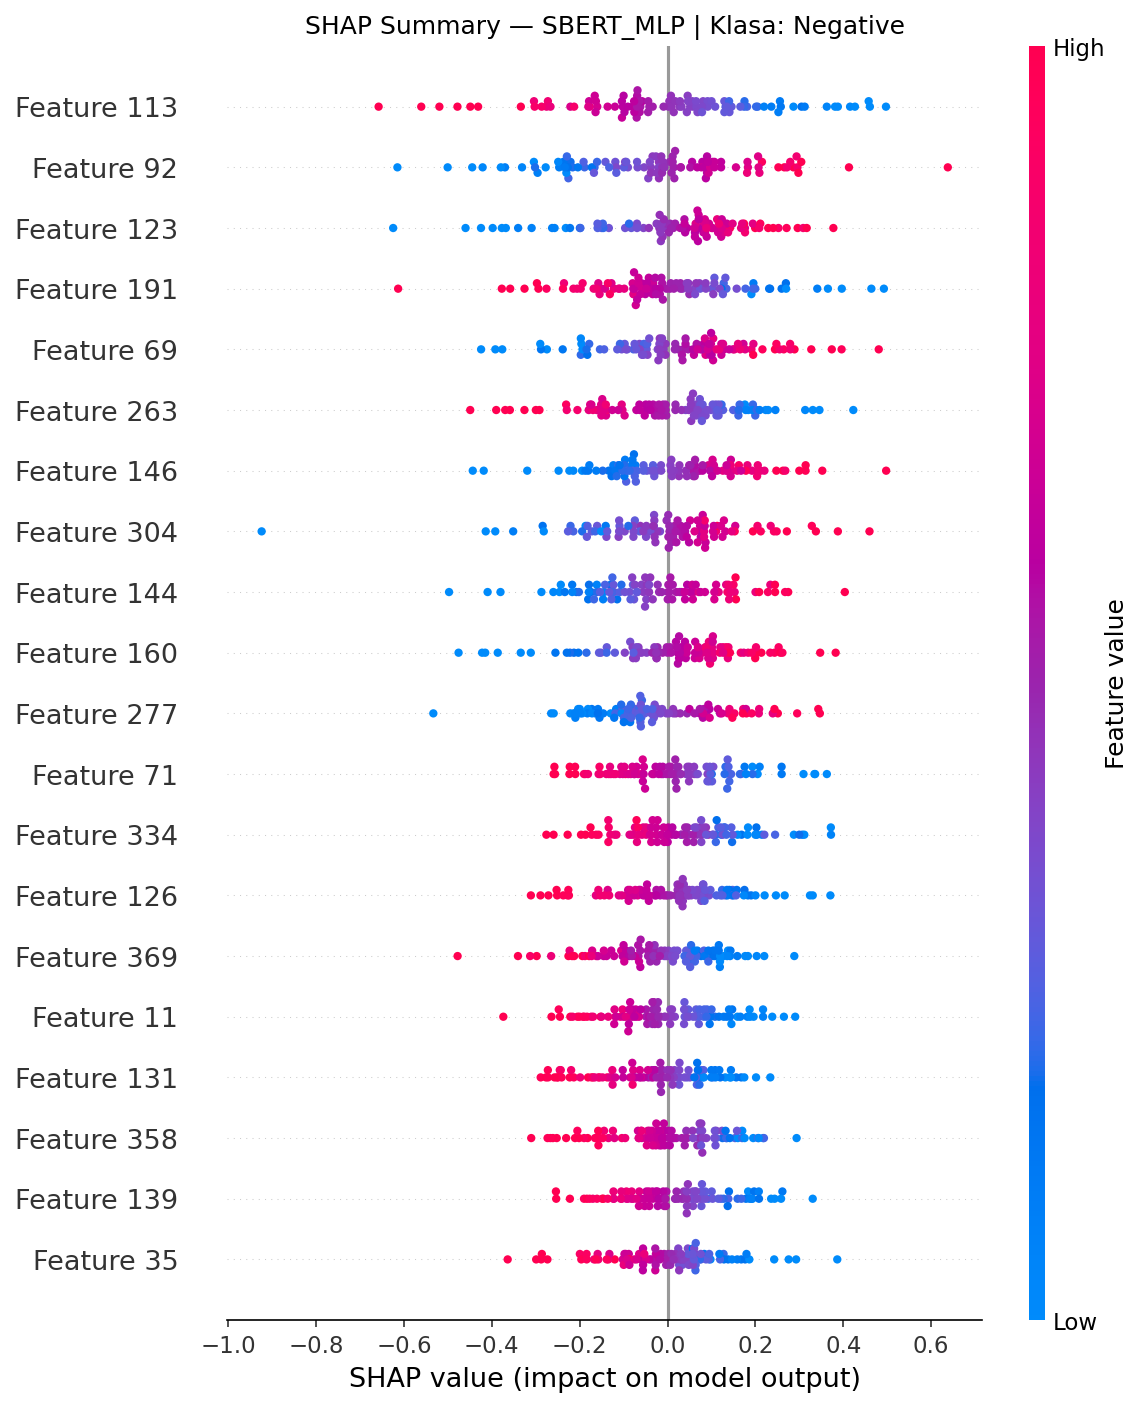

In [21]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_summary_SBERT_MLP_class0.png"), width=800))


#### Klasa: Neutral


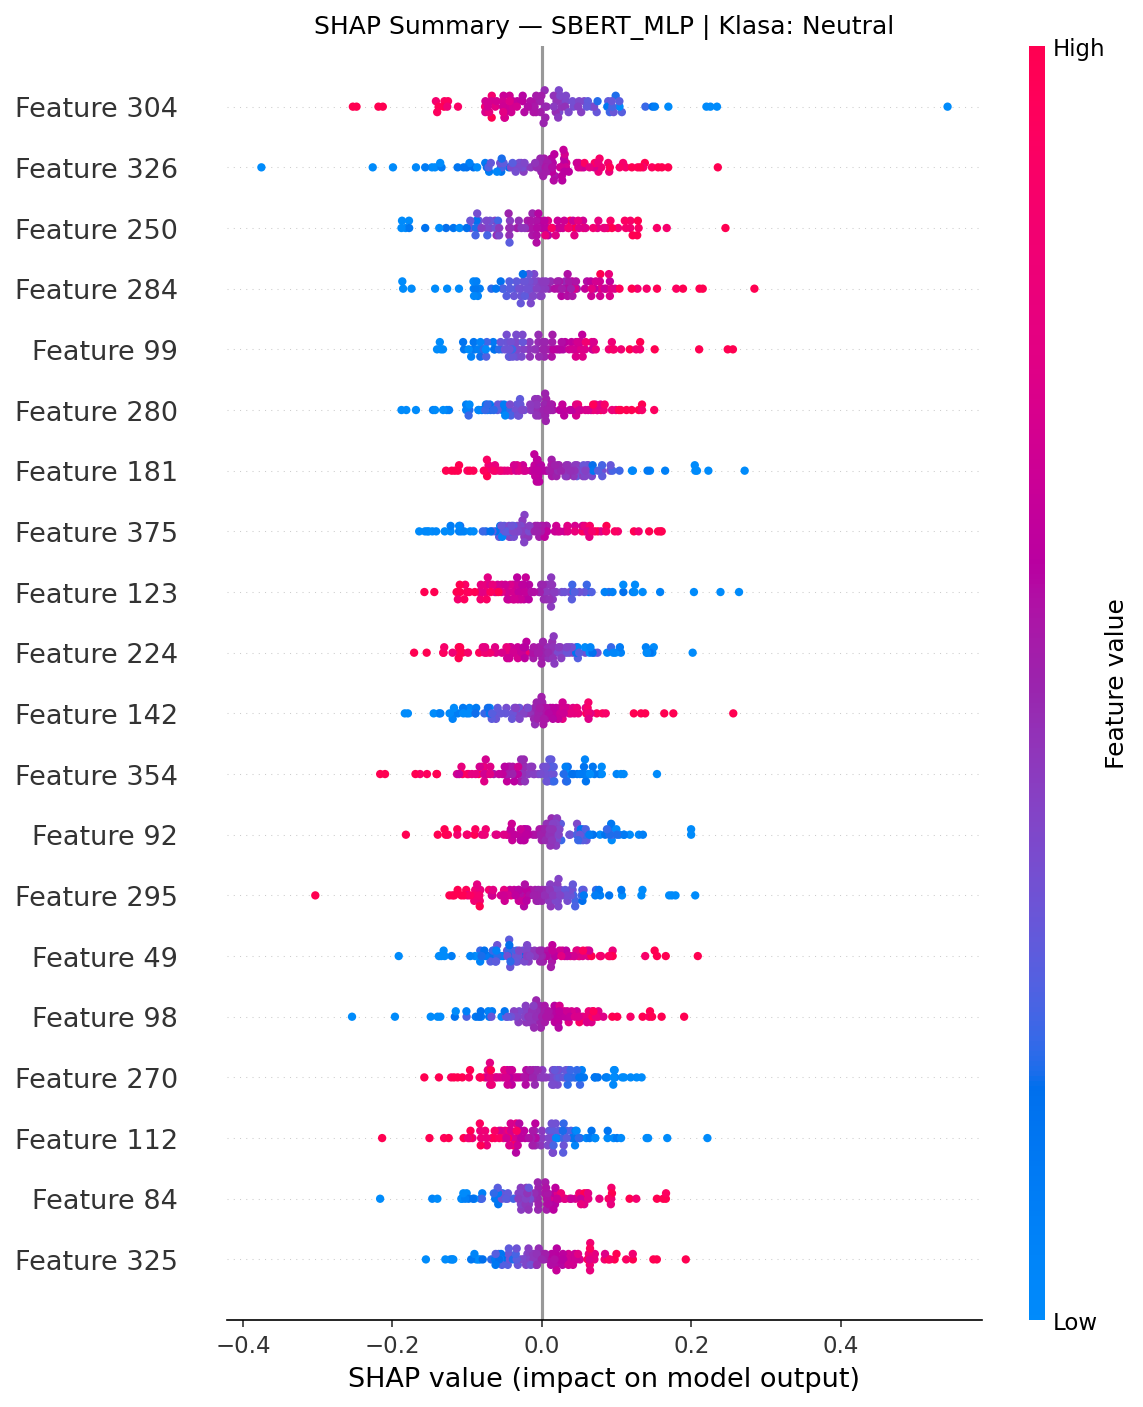

In [22]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_summary_SBERT_MLP_class1.png"), width=800))


#### Klasa: Positive


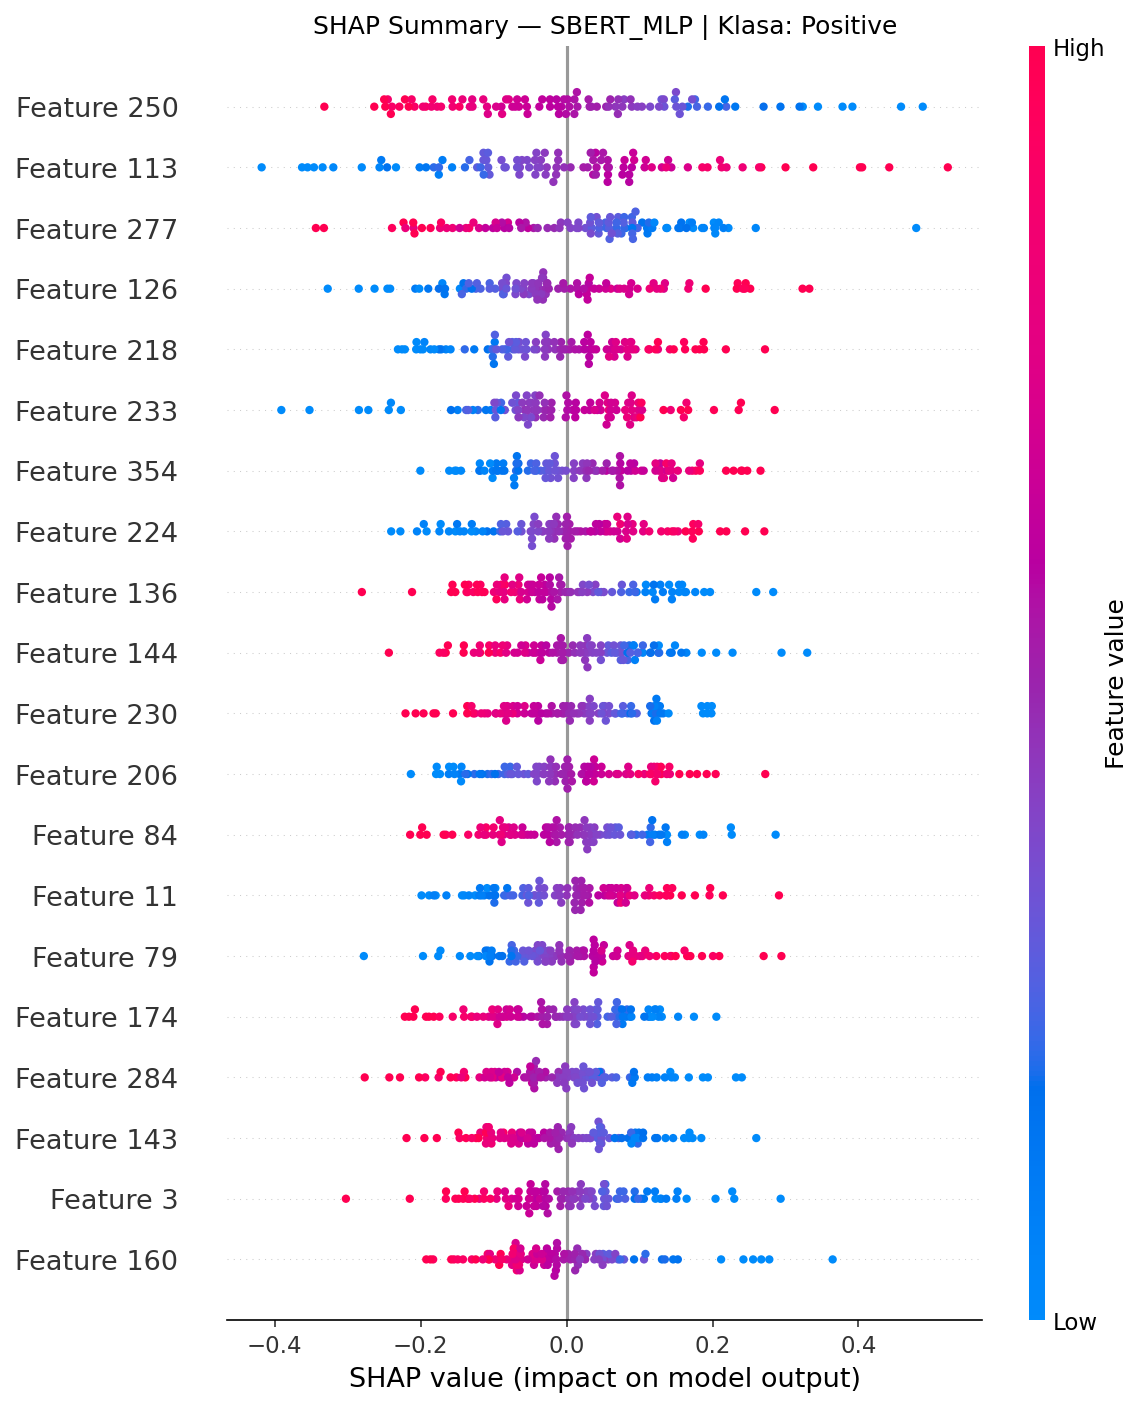

In [23]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_summary_SBERT_MLP_class2.png"), width=800))


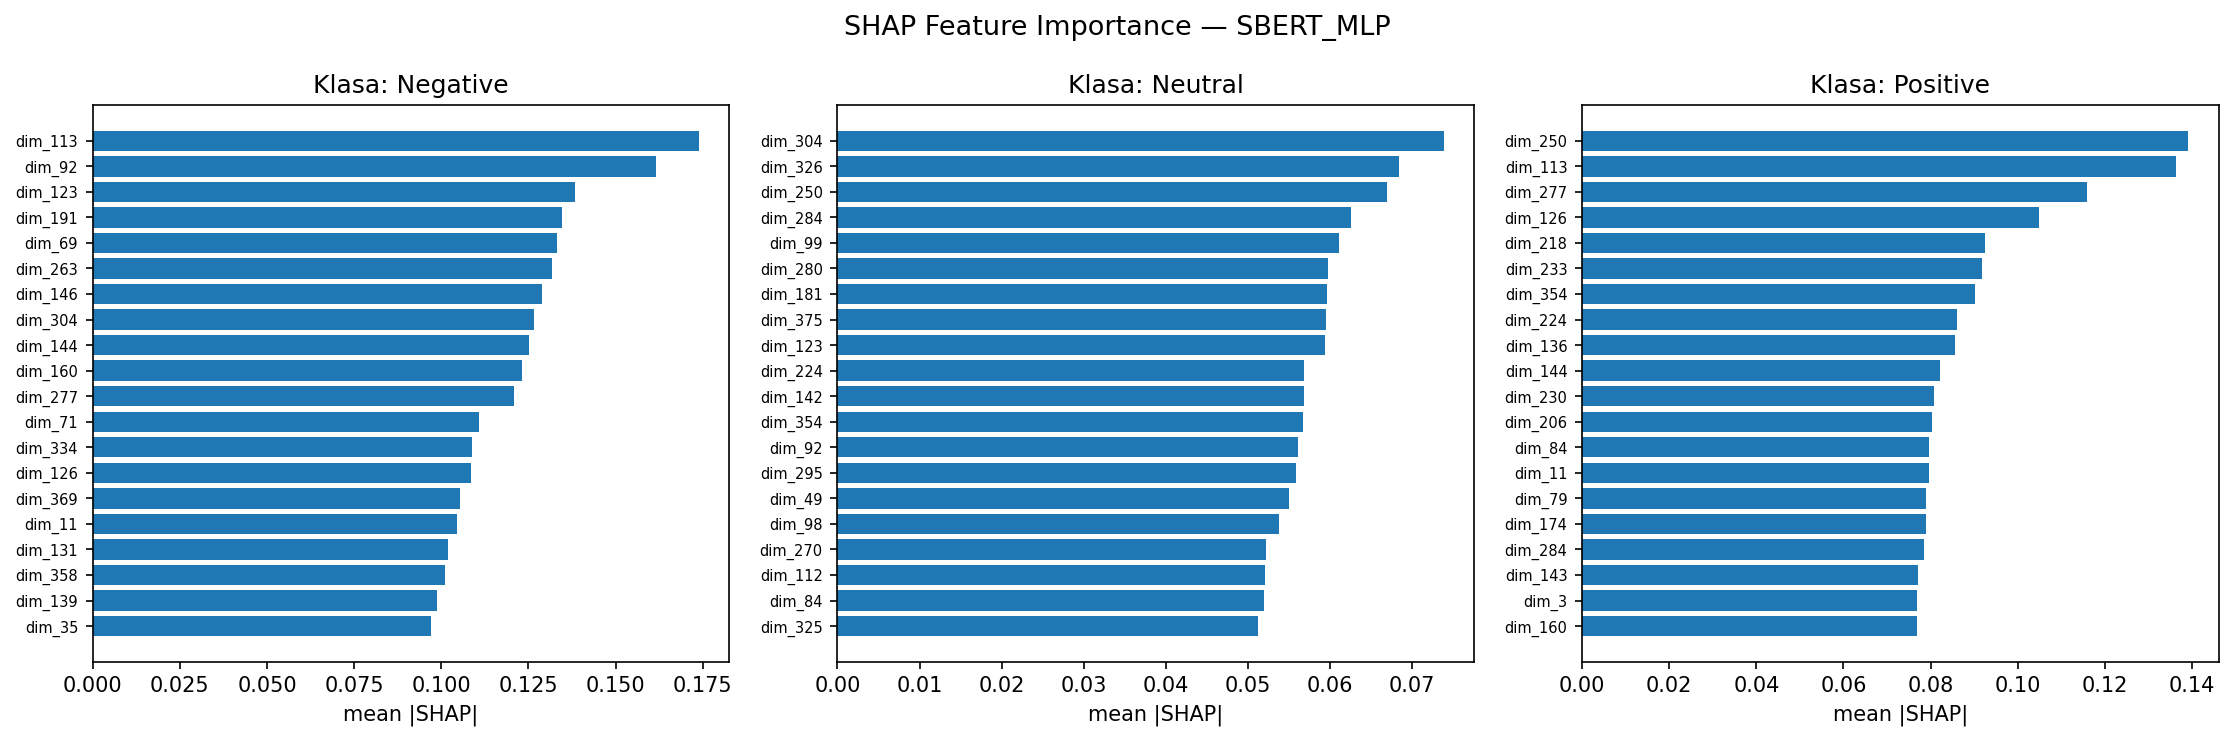

In [24]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_bar_SBERT_MLP.png"), width=800))


**Interpretacja SHAP dla SBERT:**

Podobnie jak w Podejściu 1, cechy odpowiadają wymiarom przestrzeni embeddingów (384-dim).

- **dim_113** i **dim_92** mają największy wpływ na klasę Negative — i jednocześnie pojawiają się
  w top cechach dla Positive z przeciwnym znakiem. Sugeruje to, że SBERT naucza wyraźnego
  **osi sentymentu** wzdłuż tych wymiarów.
- **dim_250** dominuje dla Positive i jednocześnie nie pojawia się w top cechach dla Negative
  — jest to cecha specyficzna dla pozytywnego sentymentu.
- Dla klasy Neutral **dim_304** i **dim_326** mają najwyższy wpływ — wymiary te wydają się
  kodować "brak silnego sentymentu".
- Mniejsze wartości mean |SHAP| dla Neutral (0.05–0.07 vs 0.1–0.17 dla Negative) potwierdzają
  trudność modelu z tą klasą.


### 6.3 SHAP — Baseline TF-IDF (interpretacja słowna)


#### Klasa: Negative


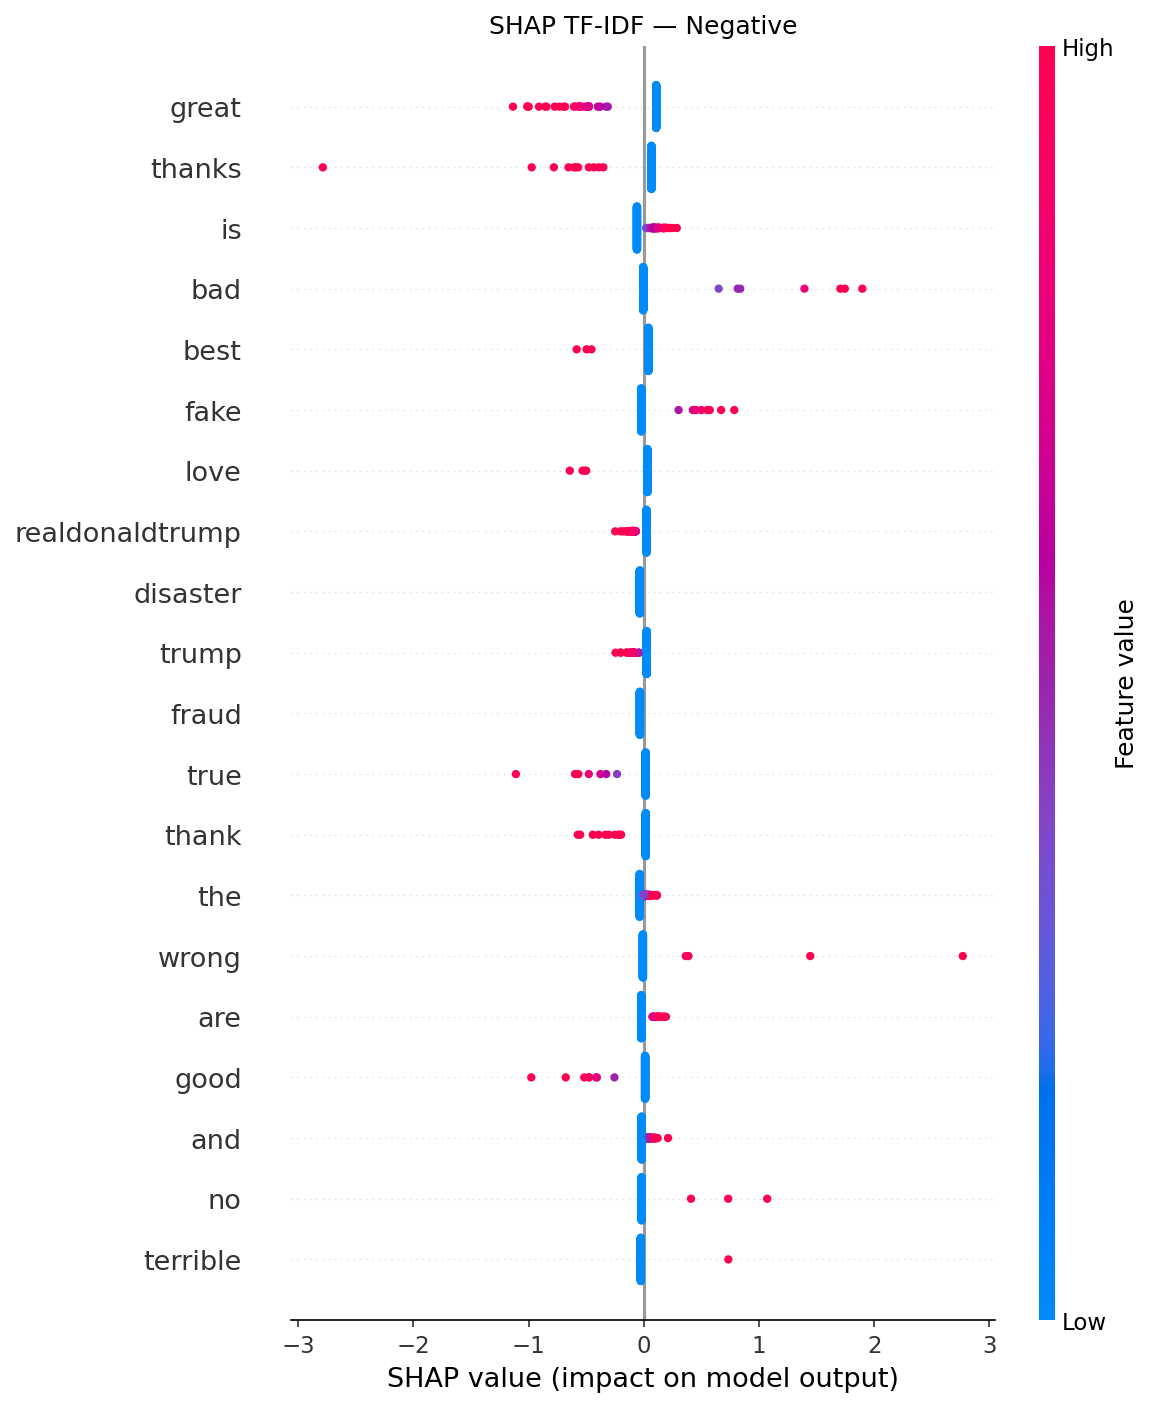

In [25]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_tfidf_baseline_class0.png"), width=800))


#### Klasa: Neutral


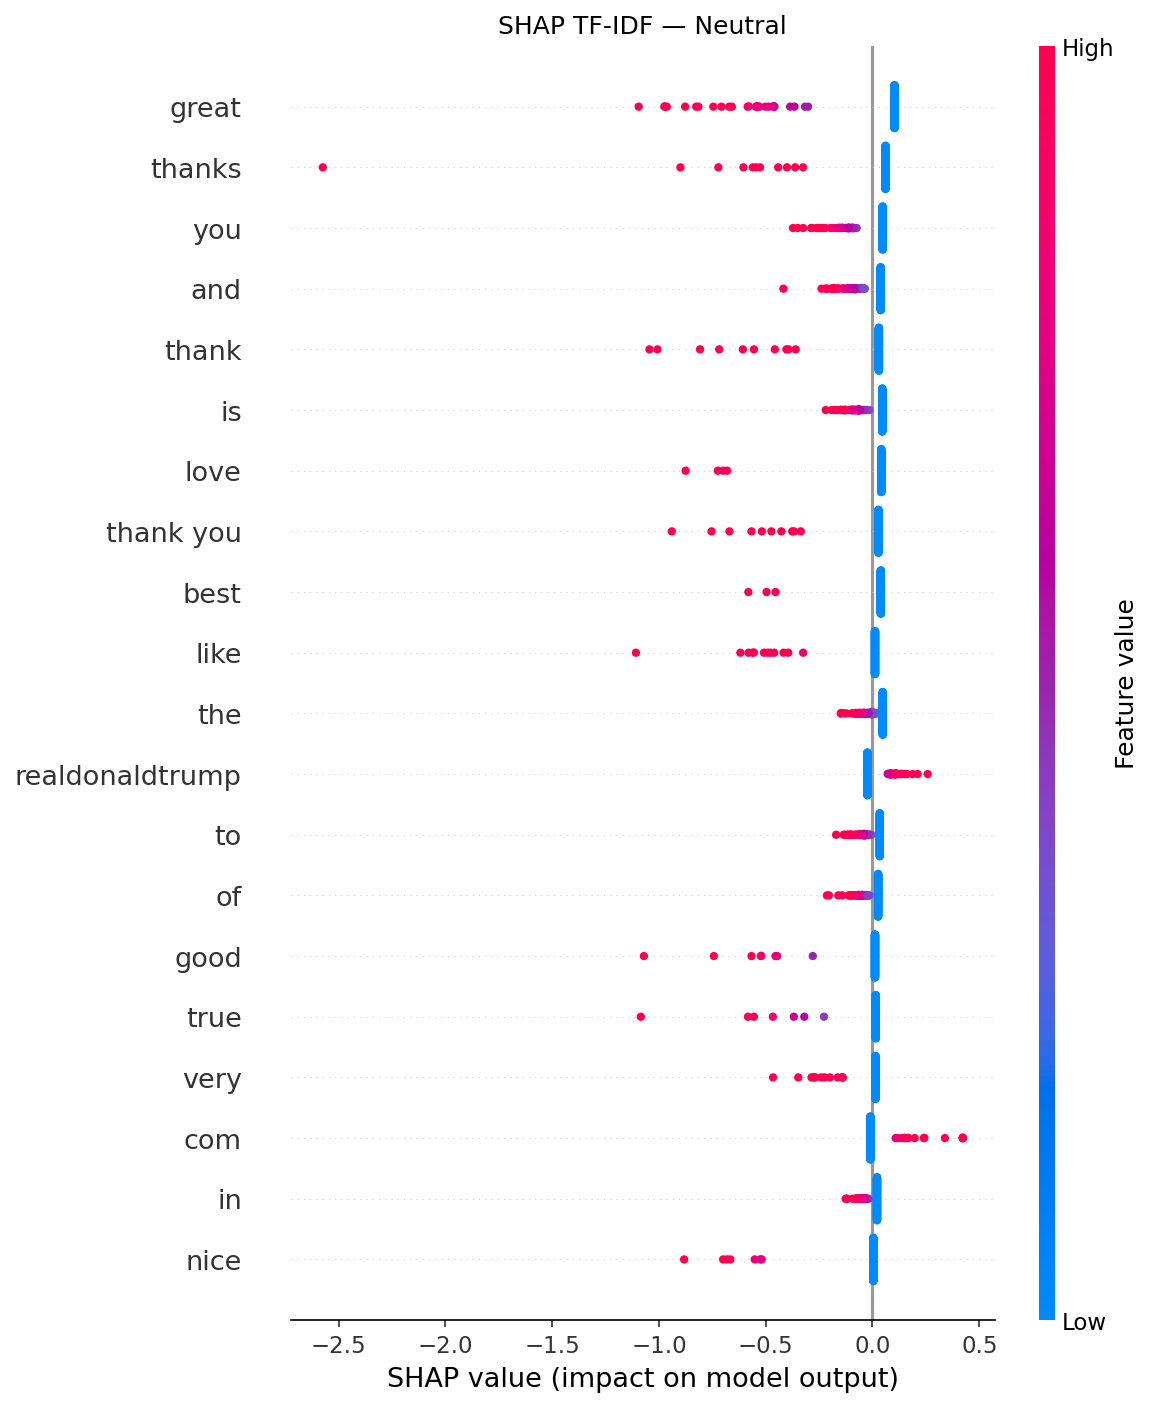

In [26]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_tfidf_baseline_class1.png"), width=800))


#### Klasa: Positive


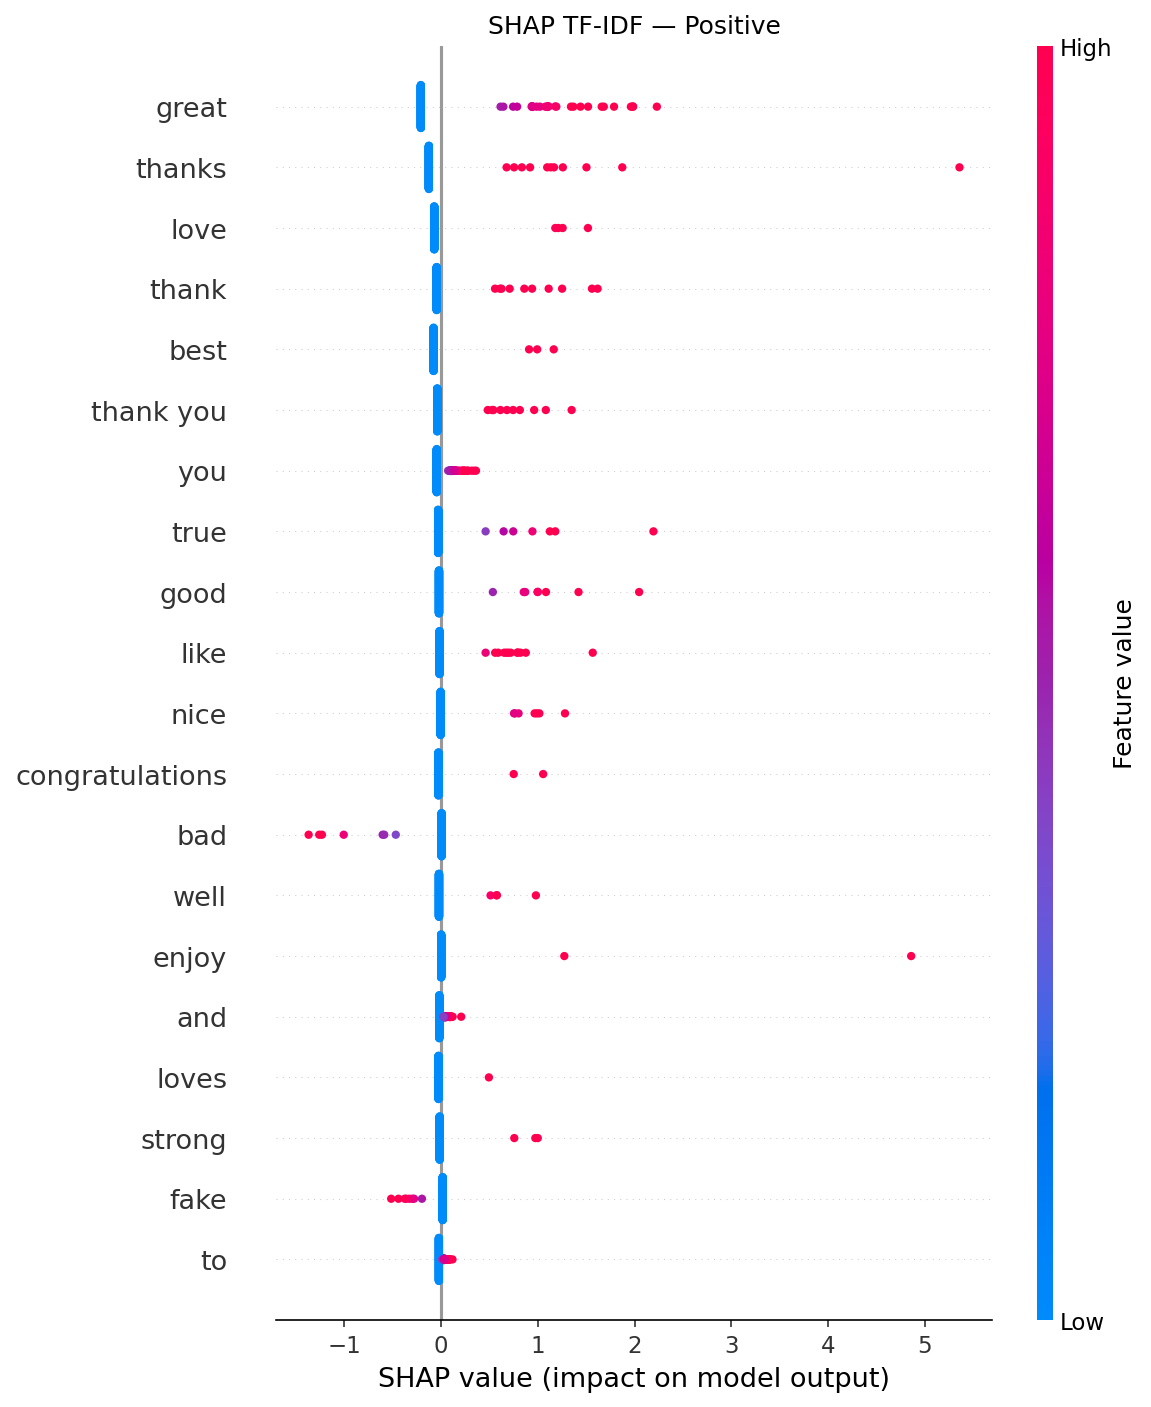

In [27]:
from IPython.display import Image, display
display(Image(filename=os.path.join(PROJECT_DIR, "plots/shap_tfidf_baseline_class2.png"), width=800))


**Interpretacja SHAP dla TF-IDF — to najczytelniejsza analiza:**

**Klasa Positive:**
- Słowa o największym dodatnim wpływie: *great* (SHAP ~1.5), *thanks*, *thank you*, *love*, *best*, *good*, *nice*, *congratulations*.
- *fake* ma silnie **ujemny** wpływ na Positive — obecność tego słowa wyklucza pozytywny sentyment.

**Klasa Negative:**
- Słowa *bad*, *fake*, *wrong*, *terrible*, *disaster*, *fraud* zwiększają prawdopodobieństwo klasy Negative.
- *great*, *thanks*, *love* mają silnie ujemny wpływ — wykluczają negatywny sentyment.
- Obecność słowa *is* (czasownik posiłkowy) pozytywnie wpływa na Negative — tweety faktograficzne
  ("X is bad/wrong") są charakterystyczne dla stylu krytycznego Trumpa.

**Klasa Neutral:**
- *great* i *thanks* mają silnie **ujemny** wpływ — ich obecność wyklucza klasę Neutral.
- Cechy faktograficzne (*realdonaldtrump*, *com*, stopwords) lekko zwiększają Neutral.
- Jest to klasa "domyślna" — tweety bez wyraźnych markerów emocji.

**Ciekawy wniosek:** Słowo *great* jest przez VADER i TF-IDF traktowane jako silnie pozytywne,
co jest charakterystyczne dla stylu Trumpa — używa go bardzo często niezależnie od faktycznego sentymentu tweetu.


---
## 7. Dyskusja wyników

### 7.1 Porównanie podejść

Oba modele embeddingowe osiągają **identyczną accuracy (74.8%)**, a różnice w F1 są minimalne.
Świadczy to o tym, że **głównym ograniczeniem jest jakość etykiet VADER**, a nie architektura
ani metoda reprezentacji tekstu.

SBERT nieznacznie przewyższa DistilBERT w F1 Macro (0.710 vs 0.698), co oznacza że lepiej
radzi sobie z klasami mniejszościowymi. Jest to zgodne z oczekiwaniami — SBERT był
fine-tunowany właśnie pod kątem rozróżniania zdań semantycznie.

### 7.2 Interpretowalność modeli

| Aspekt | TF-IDF + LogReg | MLP (DistilBERT/SBERT) |
|---|---|---|
| **Interpretowalność SHAP** | Wysoka — konkretne słowa | Niska — abstrakcyjne wymiary |
| **Accuracy** | 80% | 74.8% |
| **Uwzględnienie kontekstu** | Nie | Tak (uwaga BERT) |
| **Odporność na OOV** | Niska | Wysoka |

Jest to klasyczny **trade-off interpretowalności**: modele oparte na embeddingach są mocniejsze
semantycznie, ale ich decyzje są trudniejsze do wyjaśnienia w kategoriach słów.

### 7.3 Ograniczenia projektu

1. **Szum etykiet VADER** — VADER nie rozumie sarkazmu, ironii ani kontekstu politycznego.
   Tweety takie jak *"Fake News media is great!"* mogą być błędnie etykietowane.

2. **Niezbalansowanie klas** — 53% tweetów Positive powoduje, że modele są nagradzane
   za przewidywanie tej klasy. Techniki takie jak class weighting lub oversampling
   mogłyby poprawić wyniki dla Neutral i Negative.

3. **Brak fine-tuningu BERT** — embeddingi DistilBERT i SBERT są "zamrożone".
   Fine-tuning całego modelu na danych z etykietami VADER prawdopodobnie
   poprawiłby wyniki, ale kosztem czasu i zasobów.

4. **SHAP na embeddingach** jest ograniczonej interpretowalności — wymiary przestrzeni
   ukrytej BERT nie mają przypisanego znaczenia semantycznego.
   Pełna interpretowalność wymagałaby np. Integrated Gradients na poziomie tokenów.

### 7.4 Wnioski końcowe

- Analiza SHAP dla baseline TF-IDF ujawniła słowa kluczowe charakterystyczne dla każdej klasy
  (*great*, *fake*, *bad*, *love*, *disaster*), co jest spójne z intuicją i stylem Trumpa.
- Modele embeddingowe, mimo niższej accuracy od baseline, oferują lepsze rozumienie
  semantyki zdań i są bardziej odporne na zmiany słownictwa.
- Wyniki SHAP dla obu modeli MLP pokazują, że klasyfikator opiera się na **niewielu wymiarach
  dominujących** (dim_229, dim_113) — co sugeruje dobrze nauczoną reprezentację sentymentu
  w przestrzeni embeddingowej.
